In [1]:
from river import stream 
from river import datasets
from river import tree, ensemble, forest
from river import metrics
from river import compose, preprocessing, linear_model
from river import feature_extraction
from river import drift
from itertools import islice
from river import base
import matplotlib as plt
metric = metrics.MSE() 
import itertools
from tqdm import tqdm
# import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import warnings
from geopy.distance import geodesic
import numpy as np
from collections import defaultdict,deque

In [2]:
# Na calym datasecie
# Manhattan        921379
# Queens            58774
# Brooklyn          18071
# Bronx               877
# NaN                 855
# Staten Island        44

In [3]:
# %pip install geopandas shapely pyproj pyogrio --no-cache-dir

In [4]:
#%pip install geopy

In [5]:
data=datasets.Taxis()
data

Taxi ride durations in New York City.

The goal is to predict the duration of taxi rides in New York City.

References
----------
[^1]: [New York City Taxi Trip Duration competition on Kaggle](https://www.kaggle.com/c/nyc-taxi-trip-duration)

      Name  Taxis                                                    
      Task  Regression                                               
   Samples  1,458,644                                                
  Features  8                                                        
    Sparse  False                                                    
      Path  /root/river_data/Taxis/train.csv                         
       URL  https://maxhalford.github.io/files/datasets/nyc_taxis.zip
      Size  186.23 MiB                                               
Downloaded  True                                                     

In [6]:
x, y = next(iter(data))
x

{'vendor_id': '2',
 'pickup_datetime': datetime.datetime(2016, 1, 1, 0, 0, 17),
 'passenger_count': 5,
 'pickup_longitude': -73.98174285888672,
 'pickup_latitude': 40.71915817260742,
 'dropoff_longitude': -73.93882751464845,
 'dropoff_latitude': 40.82918167114258,
 'store_and_fwd_flag': 'N'}

In [7]:
class FeatureDistrict(base.Transformer):
    
    def __init__(self):
        nyc_boroughs = gpd.read_file("nybb.shp")
        nyc_boroughs = nyc_boroughs.to_crs(epsg=4326)

        self.boroughs_list = [
            (row['geometry'], row['BoroName']) 
            for i, row in nyc_boroughs.iterrows()
        ]

    def which_dist(self, lat, lon):
        punkt = Point(lon, lat)
        
        for b_geom, b_name in self.boroughs_list:
            if b_geom.contains(punkt):
                return b_name
        return "Outside_NYC"
    
    def which_dist_2(self, lat, lon): #recznie nieuzywany juz 
        if 40.70 <= lat <= 40.88 and -74.02 <= lon <= -73.91:
            return "Manhattan"
        elif 40.56 <= lat <= 40.74 and -74.04 <= lon <= -73.83:
            return "Brooklyn"
        elif 40.54 <= lat <= 40.80 and -73.96 <= lon <= -73.70:
            return "Queens"
        elif 40.80 <= lat <= 40.92 and -73.93 <= lon <= -73.76:
            return "Bronx"
        else:
            return "Outside_NYC"

    def transform_one(self, x):
        x = x.copy()
        
        dt = x["pickup_datetime"]
        hour = dt.hour
        x["hour"] = hour
        x["day_of_week"] = dt.weekday()
        x["is_weekend"] = int(dt.weekday() >= 5)

        pickup_d = self.which_dist(x["pickup_latitude"], x["pickup_longitude"])
        dropoff_d = self.which_dist(x["dropoff_latitude"], x["dropoff_longitude"])

        x["pickup_district"] = pickup_d
        x["dropoff_district"] = dropoff_d

        x["within_district"] = int(
            pickup_d == dropoff_d and pickup_d != "Outside_NYC" and dropoff_d !="Outside_NYC"
        )
        a = (x["pickup_latitude"], x["pickup_longitude"])
        b = (x["dropoff_latitude"], x["dropoff_longitude"])
        dist = geodesic(a, b).kilometers
        x["distance"] = dist

        #x["store_and_fwd_flag"] = 1 if x["store_and_fwd_flag"] == "Y" else 0

        remove = ["vendor_id", "store_and_fwd_flag", "passenger_count","pickup_datetime",]
        for k in remove:
            x.pop(k, None)

        return x

In [8]:
x, y = next(iter(data))
x

{'vendor_id': '2',
 'pickup_datetime': datetime.datetime(2016, 1, 1, 0, 0, 17),
 'passenger_count': 5,
 'pickup_longitude': -73.98174285888672,
 'pickup_latitude': 40.71915817260742,
 'dropoff_longitude': -73.93882751464845,
 'dropoff_latitude': 40.82918167114258,
 'store_and_fwd_flag': 'N'}

In [9]:
y

849

In [10]:
transformer = FeatureDistrict()
x_2 = transformer.transform_one(x)
x_2

{'pickup_longitude': -73.98174285888672,
 'pickup_latitude': 40.71915817260742,
 'dropoff_longitude': -73.93882751464845,
 'dropoff_latitude': 40.82918167114258,
 'hour': 0,
 'day_of_week': 4,
 'is_weekend': 0,
 'pickup_district': 'Manhattan',
 'dropoff_district': 'Manhattan',
 'within_district': 1,
 'distance': 12.74390022449115}

In [11]:
dt = x["pickup_datetime"]
#dt = datetime.datetime.strptime(dt, "%Y-%m-%d %H:%M:%S")
hour = dt.hour
hour
dt.weekday()

4

In [12]:

def createShadow():
     return forest.ARFRegressor(n_models=12, seed=0)


In [13]:
def models_dist(district):
    #scaler = preprocessing.StandardScaler()
    if district == "Manhattan":
        model = forest.ARFRegressor(n_models=10, seed=0)
    elif district == "Brooklyn":
        model = ensemble.SRPRegressor(n_models=10, seed=0)
    elif district == "Queens":
         model = forest.ARFRegressor(n_models=13, seed=0)
    elif district == "Bronx":
        model = ensemble.SRPRegressor(n_models=13, seed=0)
    elif district == "Global":
        model = forest.ARFRegressor(n_models=10, seed=0)
    elif district == "Staten Island":
        model = forest.ARFRegressor(n_models=10, seed=0)
    return model


districts = ["Manhattan", "Brooklyn", "Queens", "Bronx","Global","Staten Island"]


In [14]:
s=300000 #5 min dla 300000 sample

models = {d: models_dist(d) for d in districts}
shadow_models = {d: None for d in districts}
a=0.01
# warning_detectors = {d: drift.KSWIN(alpha=0.05) for d in districts}
# drift_detectors = {d: drift.KSWIN(alpha=0.001) for d in districts}

warning_detectors = {d: drift.ADWIN(delta=0.2) for d in districts}
drift_detectors = {d: drift.ADWIN(delta=0.05) for d in districts}

plot_data = []
transformer = FeatureDistrict()
stream = data.take(s) 

In [15]:
error_series = {d: [] for d in districts}     
drift_instances = {d: [] for d in districts}  
local_counts = {d: 0 for d in districts}
window_error = {d: [] for d in districts}
window=100
time_series = {d: [] for d in districts}
drift_timestamps = {d: [] for d in districts}
drift_dist_timestamps={d: [] for d in districts}

In [16]:
configs = {
    "Manhattan": {"window_size": 500, "stat_size": 50, "alpha": 0.001},
    "Brooklyn": {"window_size": 100, "stat_size": 30, "alpha": 0.001},
    "Queens": {"window_size": 100, "stat_size": 30, "alpha": 0.001},
    "Global": {"window_size": 300, "stat_size": 20, "alpha": 0.001},

    "Bronx": {"window_size": 10, "stat_size": 5, "alpha": 0.001},
    "Staten Island": {"window_size": 10, "stat_size": 5, "alpha": 0.001},

}

distribution_detectors = {
    d: drift.KSWIN(
        window_size=params["window_size"],
        stat_size=params["stat_size"],
        alpha=params["alpha"]
    )
    for d, params in configs.items()
}

In [17]:
# x, y = next(iter(data))

# timestamp = x["pickup_datetime"]

# x = transformer.transform_one(x)
# if x["within_district"] == 1:
#     district = x["pickup_district"]
# else:
#     district="Global"
# x.pop("pickup_district",None)
# x.pop("pickup_district",None)
# x


In [18]:
centroid_windows = defaultdict(lambda: deque(maxlen=window))
centroid_ref = {}
centroid_drift_log = defaultdict(list)
centroid_adwin = {d: drift.ADWIN(delta=0.05) for d in districts}
from collections import defaultdict

In [19]:
def centroid(X):
    if len(X) == 0:
        return None
    return np.mean(X, axis=0)

In [20]:
def centroid_distance(c1, c2):
    return np.linalg.norm(c1 - c2) #sprawdzic inna Mahalanobis?

In [21]:
for x, y in tqdm(stream, total=s, desc="Done"):
    timestamp = x["pickup_datetime"]
    
    x = transformer.transform_one(x)
    if x["within_district"] == 1:
        district = x["pickup_district"]
    else:
        district="Global"
    x.pop("pickup_district",None)
    x.pop("dropoff_district",None)
    
    model = models[district]
    
    y_pred = model.predict_one(x)
    local_counts[district] += 1
    instanceCount = local_counts[district]
    if y_pred is not None:
        
        msa=abs(y_pred - y)
        error =abs(y_pred - y)/(y + 0.01)

        distribution_detect=distribution_detectors[district]
        distribution_detect.update(x["dropoff_longitude"])
        
        warning=warning_detectors[district]
        drift=drift_detectors[district]
        warning.update(msa)
        drift.update(msa)
        
        error_series[district].append(error)
        current_window = error_series[district][-window:]
        current_rolling_mae = sum(current_window) / len(current_window)
        window_error[district].append(current_rolling_mae)
        time_series[district].append(timestamp)

        if instanceCount > 100:
            if distribution_detect.drift_detected:
                print(f"DISTRIBUTION SHIFT DRIFT DETECTED in {district} at count:{instanceCount}")
                drift_dist_timestamps[district].append(timestamp)
                
            if warning.drift_detected:
                if shadow_models[district] is None:
                    print(f"WARNING in {district} at count:{instanceCount}")
                    shadow_models[district] = createShadow()
                    shadow_models[district].learn_one(x,y)
    
            if drift.drift_detected:
                print(f"DRIFT DETECTED in {district} at count:{instanceCount}")
                drift_instances[district].append(local_counts[district])
                drift_timestamps[district].append(timestamp)
                if shadow_models[district] is not None:
                    models[district] = shadow_models[district]
                    shadow_models[district] = None 
               # else: models[district] = createShadow()

        #Centroid jaki detector?
        feature_vec = np.array(list(x.values()), dtype=float)
        centroid_windows[district].append(feature_vec)
        
        if len(centroid_windows[district]) == window:
        
            current_centroid = centroid(centroid_windows[district])
        
            if district not in centroid_ref:
                centroid_ref[district] = current_centroid
            else:
                dist = centroid_distance(current_centroid, centroid_ref[district])
                centroid_adwin[district].update(dist)
        
                if centroid_adwin[district].drift_detected:
                    print(f"CENTROID DRIFT DETECTED in {district} at {instanceCount}")
                    centroid_drift_log[district].append({
                        "time": timestamp,
                        "instance": instanceCount
                    })
        
                centroid_ref[district] = current_centroid





        
        model.learn_one(x, y)
    

Done:   1%|          | 2127/300000 [00:01<03:59, 1246.05it/s]

WARNING in Brooklyn at count:128


Done:   1%|          | 3254/300000 [00:02<03:57, 1248.32it/s]

DISTRIBUTION SHIFT DRIFT DETECTED in Global at count:647
WARNING in Manhattan at count:2304


Done:   1%|▏         | 4041/300000 [00:03<03:39, 1348.69it/s]

...

Done:  99%|█████████▉| 296916/300000 [06:05<00:03, 795.86it/s]

CENTROID DRIFT DETECTED in Global at 36036
DISTRIBUTION SHIFT DRIFT DETECTED in Manhattan at count:252671


Done:  99%|█████████▉| 298408/300000 [06:06<00:01, 802.45it/s]

DISTRIBUTION SHIFT DRIFT DETECTED in Manhattan at count:253890


Done: 100%|██████████| 300000/300000 [06:09<00:00, 812.90it/s]


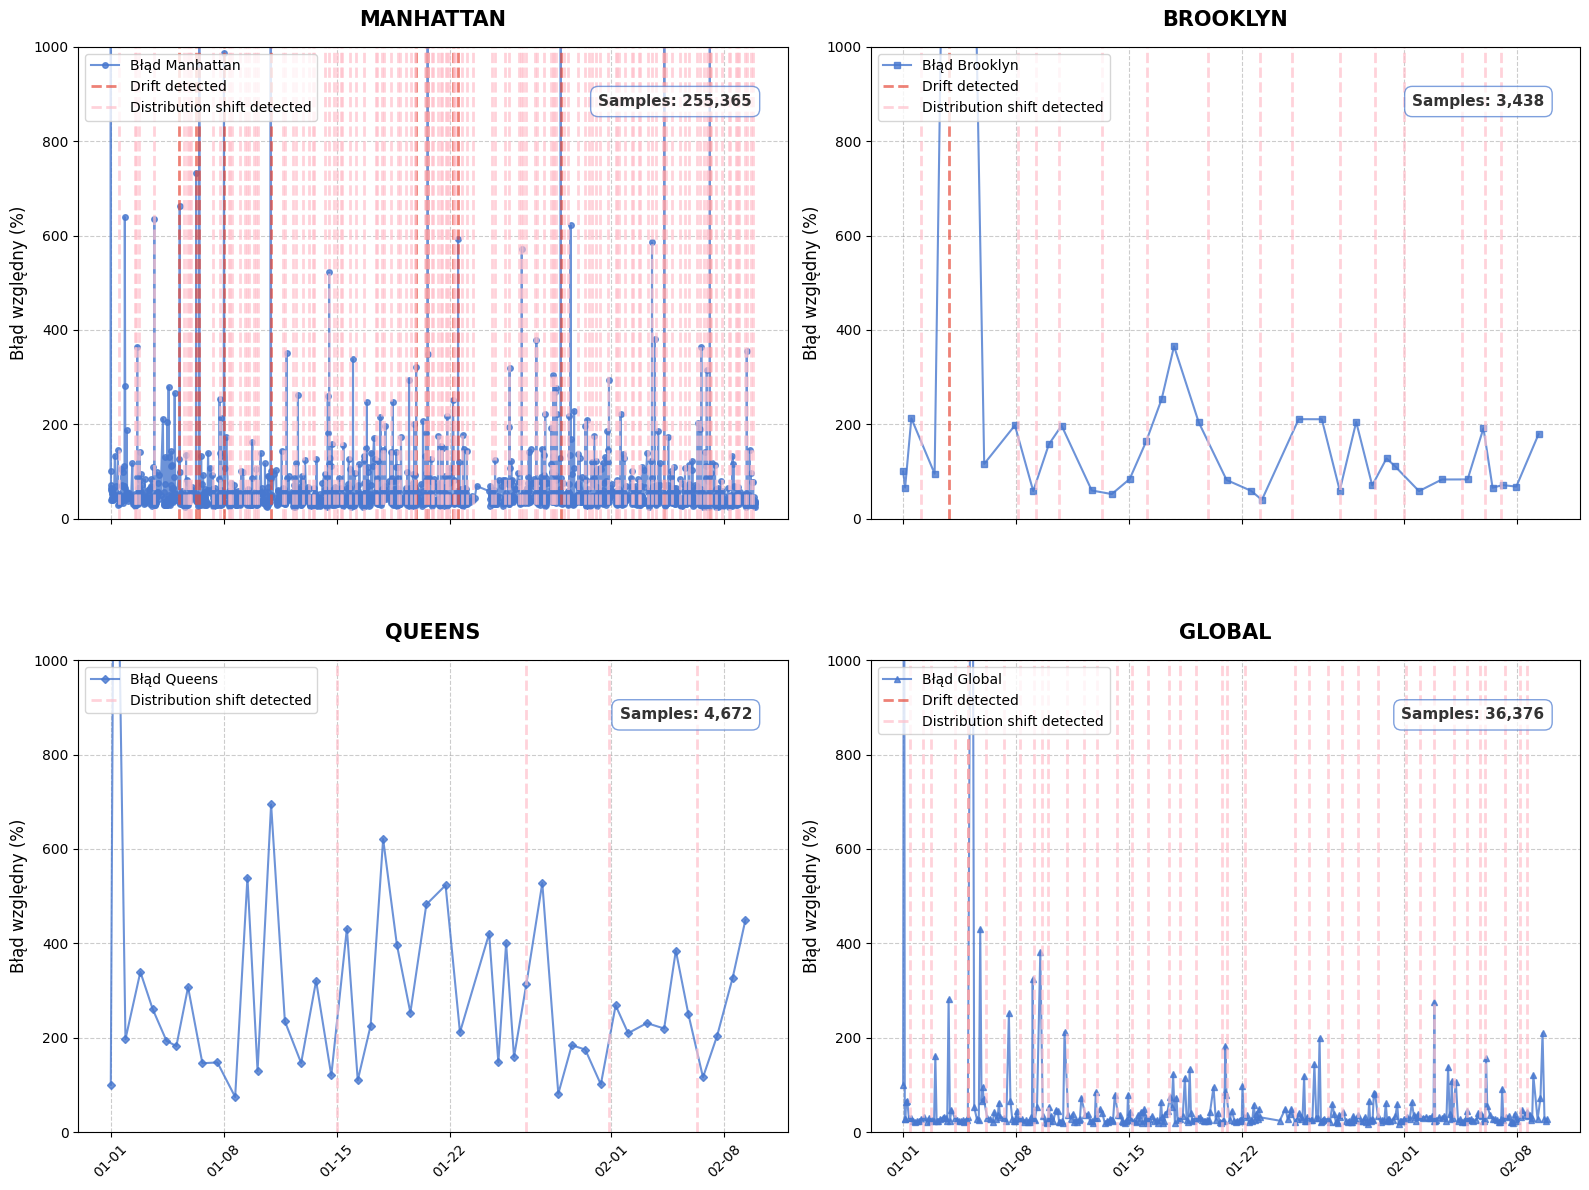

In [22]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import itertools
import pandas as pd


plt.style.use('seaborn-v0_8-muted')
marker = itertools.cycle(('o', 's', 'D', '^', 'v'))
district_list = ["Manhattan", "Brooklyn", "Queens", "Global"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for idx, dist in enumerate(district_list):
    ax = axes[idx]
    
    series = window_error.get(dist, [])
    times = time_series.get(dist, [])
    
    times = pd.to_datetime(times)
    series_pct = [e * 100 for e in series]

    times_plot = times[::100]
    series_plot = series_pct[::100]
    line_ref = ax.plot(
        times_plot,
        series_plot,
        label=f"Błąd {dist}",
        marker=next(marker),
        markersize=4,
        linewidth=1.5,
        alpha=0.8
    )[0]


    color = line_ref.get_color()
    count = local_counts.get(dist, 0)

    ax.text(0.95, 0.90, f"Samples: {count:,}", 
            transform=ax.transAxes, 
            verticalalignment='top', 
            horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7, edgecolor=color),
            fontsize=11, fontweight='bold', color='#333333')

    if dist in drift_timestamps:
        for i, t in enumerate(drift_timestamps[dist]):
            lbl = "Drift detected" if i == 0 else ""
            ax.axvline(
                pd.to_datetime(t),
                color="#e74c3c", 
                linestyle='--',
                linewidth=2,
                alpha=0.7,
                label=lbl
            )
    if dist in drift_timestamps:
        for i, t in enumerate(drift_dist_timestamps[dist]):
            lbl = "Distribution shift detected" if i == 0 else ""
            ax.axvline(
                pd.to_datetime(t),
                color="pink", 
                linestyle='--',
                linewidth=2,
                alpha=0.7,
                label=lbl
            )

    ax.set_title(dist.upper(), fontsize=15, fontweight='bold', pad=15)
    ax.set_ylim(0, 1000)
    ax.set_ylabel("Błąd względny (%)", fontsize=12)
    

    ax.grid(True, which='major', linestyle='--', alpha=0.4, color='gray')
    

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.tick_params(axis='x', rotation=45, labelsize=10)


    if dist in drift_timestamps:
        ax.legend(loc='upper left', frameon=True, facecolor='white')

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()